In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5.4')

small_llm = ChatOpenAI(model='gpt-5.4-mini')

In [3]:
# from langchain_openai import AzureChatOpenAI

# llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-2024-11-20',
#     api_version='2024-08-01-preview',   
# )

# small_llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-mini-2024-07-18',
#     api_version='2024-08-01-preview',
# )

In [4]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


In [6]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

C:\Users\cleft\AppData\Local\Temp\ipykernel_1380\3256258543.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\cleft\AppData\Local\Temp\ipykernel_1380\3256258543.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [7]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001C5442E8350>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001C5442E8350>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001C5442E8350>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001C5442E8350>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000001C5442E8350>)]

In [8]:
# from langchain.agents import load_tools

# tools = load_tools(
#     ["arxiv"],
# )
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

loaded_tool_list = [arxiv]

In [9]:
loaded_tool_list


[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=3, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000))]

In [10]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool


embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
        collection_name="real_estate_tax",
        persist_directory="./real_estate_tax_collection",
        embedding_function=embeddings
    )

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to April 2026'
)


In [11]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list +loaded_tool_list
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [12]:
# multiply.invoke({'a': 3, 'b': 5})

In [13]:
# from langchain_core.messages import HumanMessage

# ai_message = llm_with_tools.invoke('3에다 5를 더하면?')

In [14]:
# ai_message

In [15]:
# tool_node.invoke({'messages': [ai_message]})

In [16]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [17]:
from langchain_core.messages import SystemMessage


def agent(state: AgentState) -> AgentState:
    messages = state['messages']
    print(f'messages length == {len(messages)}')
    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
        
    print(f'agent_messages_with_summary == {messages}')    
    response = llm_with_tools.invoke(messages)
    # print(f"agent messages == {response} ")
    
    return {'messages': [response]}

In [18]:
from typing import Literal
from langgraph.types import Command, interrupt


def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt({
        'question': '이렇게 진행하면 될까?',
        'tool_call': tool_call
    })
    review_action = human_review['action']
    review_data = human_review.get('data', None)

    if review_action == 'continue':
        return Command(goto='tools')

    if review_action == 'update_args':
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})

    if review_action == 'update_tool':
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',
            'content': review_data
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})



In [19]:
def summarize_messages(state: AgentState):
    messages = state['messages']
    summary = state['summary']
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
        chat_history: {messages}
        summary: {summary}'''

    summary = small_llm.invoke(summary_prompt)
    print(f'summary == {summary}')
    # response = llm_with_tools.invoke(messages)
    return {'summary': summary.content}

In [20]:
from langchain_core.messages import RemoveMessage


def delete_message(state: AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [21]:
from typing import Literal
# from langgraph.graph import END

def should_continue(state: AgentState) -> Literal['tools', 'delete_message']:
    messages = state['messages']

    print(f"should_continue messages == {messages} ")
    
    last_ai_message = messages[-1]
    
    if last_ai_message.tool_calls:
        return 'human_review'

    return 'summarize_messages'

In [22]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node('human_review', human_review)
graph_builder.add_node('delete_message', delete_message)
graph_builder.add_node('summarize_messages', summarize_messages)

In [23]:
from langgraph.graph import START, END
# from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['human_review', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_message')
graph_builder.add_edge('delete_message', END)

In [24]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
graph= graph_builder.compile(
    checkpointer=checkpointer
)

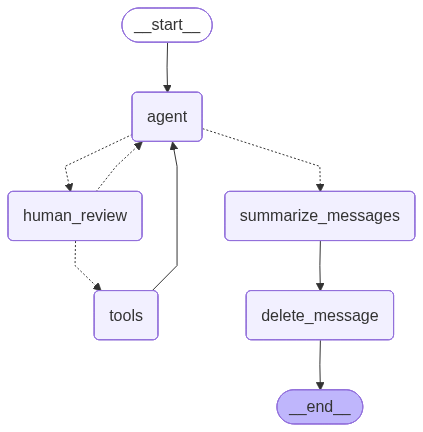

In [25]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'paper_summary'
    }
}

# query = 'what currency is in Billy Giles\' birthplace? Find the currency and email it to cleftin02@gamil.com'
# query = 'Attention is All You Need라는 논문을 요약해서 cleftin02@gamil.com으로 메일 보낼 겁니다. 우선 이메일 보낼낼 초안을 작성해 주세요'
query = '15억 일 때 종합부동산세를 계산해 줄 수 있나요?'

for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

15억 일 때 종합부동산세를 계산해 줄 수 있나요?
messages length == 1
agent_messages_with_summary == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='15599b89-ac7b-4ecf-a9b8-868a6cf43820')]
should_continue messages == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='15599b89-ac7b-4ecf-a9b8-868a6cf43820'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 843, 'total_tokens': 902, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkurm8bRKbqmGa7g4enNBCDZV9SD', 'service_tier': '

In [27]:
# current_message_list = graph.get_state(config).values['messages']
# current_message_list

In [28]:
graph.get_state(config).values['messages']

[HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='15599b89-ac7b-4ecf-a9b8-868a6cf43820'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 843, 'total_tokens': 902, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkurm8bRKbqmGa7g4enNBCDZV9SD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db9bb-1bcf-7dd2-a5e6-4647317b4291-0', tool_calls=[{'name': 'real_estate_tax_retriever', 'args': {'query': '2026년 15억원 주택 종합부동산세 계산 방법 1세대1주택자 일반 공동명의 공정시장가액비율 세율 공제'}, 'id': 'call_HWn9He5IJNP97311RUzyiJKR', 'type': 'tool_call'}], invalid_tool_calls=[], usag

In [29]:
graph.get_state(config).next

('human_review',)

In [30]:
# human_review에서 인터럽트 후에 선택된 툴과 쿼리리 그대로 툴 실행
# for chunk in graph.stream(
#     Command(resume={'action': 'continue'}),
#     config=config,
#     stream_mode='updates'
# ):
#     print(chunk)

In [31]:
# 선택된 툴은 그대로 사용하고, 쿼리 변경 후 툴 실행행
# for chunk in graph.stream(
#     Command(resume={'action': 'update_args', 'data': {'query': '51세 일반인 15억 주택 1채소유 시 종합부동산세 얼마입니까?'}}),
#     config=config,
#     stream_mode='updates'
# ):
#     print(chunk)

In [32]:
# 툴을 잘못 선택해 새로 툴 선택택
for chunk in graph.stream(
    Command(resume={'action': 'update_tool', 'data': {'query': 'real_estate_tax_retriever말고 web에서 검색해주세요요'}}),
    config,
    stream_mode='updates'
):
    print(chunk)

{'human_review': {'messages': [{'tool_call_id': 'call_HWn9He5IJNP97311RUzyiJKR', 'name': 'real_estate_tax_retriever', 'role': 'tool', 'content': {'query': 'real_estate_tax_retriever말고 web에서 검색해주세요요'}}]}}
messages length == 3
agent_messages_with_summary == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='15599b89-ac7b-4ecf-a9b8-868a6cf43820'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 843, 'total_tokens': 902, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkurm8bRKbqmGa7g4enNBCDZV9SD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db

{'human_review': {'messages': [{'tool_call_id': 'call_HWn9He5IJNP97311RUzyiJKR', 'name': 'real_estate_tax_retriever', 'role': 'tool', 'content': {'query': 'real_estate_tax_retriever말고 web에서 검색해주세요요'}}]}}
messages length == 3
agent_messages_with_summary == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='15599b89-ac7b-4ecf-a9b8-868a6cf43820'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 843, 'total_tokens': 902, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkurm8bRKbqmGa7g4enNBCDZV9SD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db9bb-1bcf-7dd2-a5e6-4647317b4291-0', tool_calls=[{'name': 'real_estate_tax_retriever', 'args': {'query': '2026년 15억원 주택 종합부동산세 계산 방법 1세대1주택자 일반 공동명의 공정시장가액비율 세율 공제'}, 'id': 'call_HWn9He5IJNP97311RUzyiJKR', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 843, 'output_tokens': 59, 'total_tokens': 902, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), ToolMessage(content="{'query': 'real_estate_tax_retriever말고 web에서 검색해주세요요'}", name='real_estate_tax_retriever', id='c113e6fd-26e5-4818-87dd-f5ce3dccc2c1', tool_call_id='call_HWn9He5IJNP97311RUzyiJKR')]
should_continue messages == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='15599b89-ac7b-4ecf-a9b8-868a6cf43820'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 843, 'total_tokens': 902, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkurm8bRKbqmGa7g4enNBCDZV9SD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db9bb-1bcf-7dd2-a5e6-4647317b4291-0', tool_calls=[{'name': 'real_estate_tax_retriever', 'args': {'query': '2026년 15억원 주택 종합부동산세 계산 방법 1세대1주택자 일반 공동명의 공정시장가액비율 세율 공제'}, 'id': 'call_HWn9He5IJNP97311RUzyiJKR', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 843, 'output_tokens': 59, 'total_tokens': 902, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), ToolMessage(content="{'query': 'real_estate_tax_retriever말고 web에서 검색해주세요요'}", name='real_estate_tax_retriever', id='c113e6fd-26e5-4818-87dd-f5ce3dccc2c1', tool_call_id='call_HWn9He5IJNP97311RUzyiJKR'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 937, 'total_tokens': 989, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkuu8Jv83adj5HPZgTRqxbiiLsBJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db9bb-2ba0-7250-ad51-1a5903fb03cd-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': '2026 종합부동산세 주택분 15억원 계산 1세대1주택 공제 공정시장가액비율 세율'}, 'id': 'call_iYqMD2QmsuttbxNiLFfAUfha', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 937, 'output_tokens': 52, 'total_tokens': 989, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})] 
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 937, 'total_tokens': 989, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkuu8Jv83adj5HPZgTRqxbiiLsBJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db9bb-2ba0-7250-ad51-1a5903fb03cd-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': '2026 종합부동산세 주택분 15억원 계산 1세대1주택 공제 공정시장가액비율 세율'}, 'id': 'call_iYqMD2QmsuttbxNiLFfAUfha', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 937, 'output_tokens': 52, 'total_tokens': 989, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}
{'__interrupt__': (Interrupt(value={'question': '이렇게 진행하면 될까?', 'tool_call': {'name': 'duckduckgo_search', 'args': {'query': '2026 종합부동산세 주택분 15억원 계산 1세대1주택 공제 공정시장가액비율 세율'}, 'id': 'call_iYqMD2QmsuttbxNiLFfAUfha', 'type': 'tool_call'}}, id='79189e5bb03eb900f4ddc06b4da1f10c'),)}

In [34]:
# human_review에서 인터럽트 후에 선택된 툴과 쿼리리 그대로 툴 실행
for chunk in graph.stream(
    Command(resume={'action': 'continue'}),
    config=config,
    stream_mode='updates'
):
    print(chunk)

{'human_review': None}
{'tools': {'messages': [ToolMessage(content='February 22, 2026 - 과세표준은 ‘(공시가격 합산 – 기본공제) x 공정시장가액비율’로 계산한다. 2026년 공정시장가액비율은 60%다. 예를 들어 1세대 1택자의 공시가격이 15억원이라면 – (15억 – 12억) x 60% = 1억 8,000만원이 과세표준이 된다. March 9, 2026 - 공정시장가액비율은 공시가격에 일정 비율을 곱하여 과세표준을 산출하는 데 사용되며 현재 60퍼센트에서 100퍼센트 범위에서 매년 정부가 결정합니다. December 8, 2025 - 1세대 1주택 판정, 공제금액, 공정시장가액비율, 세액공제 여부 등 여러 요소가 함께 작동하기 때문에 같은 금액의 주택이라도 납세자별로 결과가 크게 달라질 수 있습니다. March 20, 2026 - 과세표준 = (공시가격 합산 − 12억 원) × 공정시장가액비율(60%) January 12, 2026 - 뉴시스에 따르면, 정부는 2025년부터 한시적으로 낮췄던 공정시장가액비율을 종료하고, 법정 수준인 60%로 되돌리겠다고 밝혔어요.', name='duckduckgo_search', id='0791acd6-35d0-4dd4-81f0-45bf7ad6b7c2', tool_call_id='call_iYqMD2QmsuttbxNiLFfAUfha')]}}
messages length == 5
agent_messages_with_summary == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='15599b89-ac7b-4ecf-a9b8-868a6cf43820'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'com

In [35]:
graph.get_state(config).values['messages']

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 937, 'total_tokens': 989, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXkuu8Jv83adj5HPZgTRqxbiiLsBJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db9bb-2ba0-7250-ad51-1a5903fb03cd-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': '2026 종합부동산세 주택분 15억원 계산 1세대1주택 공제 공정시장가액비율 세율'}, 'id': 'call_iYqMD2QmsuttbxNiLFfAUfha', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 937, 'output_tokens': 52, 'total_tokens': 989, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio':